In [ ]:
# Install required packages
!pip install medmnist
!pip install torch torchvision
!pip install scikit-learn
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import make_grid
import numpy as np
import matplotlib.pyplot as plt
from medmnist import TissueMNIST, BreastMNIST, ChestMNIST, PathMNIST, DermaMNIST
import os
import zipfile
from datetime import datetime
import argparse
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import numpy as np

# Google Colab specific imports
try:
    from google.colab import files
    COLAB_ENV = True
    print("Running in Google Colab environment")
except ImportError:
    COLAB_ENV = False
    print("Not running in Google Colab")

# Create directories for saving
os.makedirs('saved_models', exist_ok=True)
os.makedirs('generated_images', exist_ok=True)

Running in Google Colab environment


In [ ]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Hyperparameters
config = {
    'batch_size': 128,
    'z_dim': 128,  # Larger latent space
    'lr': 3e-4,
    'epochs': 20,
    'beta': 0.5,   # KL-divergence weight
    'num_samples': 5  # For visualization
}

Using device: cpu


In [ ]:
def get_dataloader(dataset_name, augment=True):
    """Load MedMNIST datasets with optional augmentation"""
    datasets = {
        'tissue': TissueMNIST,
        'breast': BreastMNIST,
        'chest': ChestMNIST,
        'path': PathMNIST,
        'derma': DermaMNIST
    }

    # Define the common sequence of transforms
    transform_list = []

    # Convert to grayscale (L) or RGB first based on dataset
    if dataset_name in ['breast', 'chest']:
        transform_list.append(transforms.Lambda(lambda x: x.convert('L')))
    else:
        transform_list.append(transforms.Lambda(lambda x: x.convert('RGB')))

    # Add augmentation if needed BEFORE ToTensor
    if augment:
        transform_list.extend([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10)
        ])

    # Convert to tensor
    transform_list.append(transforms.ToTensor())

    # Repeat channel for grayscale images AFTER ToTensor
    if dataset_name in ['breast', 'chest']:
         transform_list.append(transforms.Lambda(lambda x: x.repeat(3, 1, 1)))

    # Always normalize
    transform_list.append(transforms.Normalize((0.5,), (0.5,)))


    transform = transforms.Compose(transform_list)

    train_data = datasets[dataset_name](split='train', transform=transform, download=True)
    val_data = datasets[dataset_name](split='val', transform=transform)
    test_data = datasets[dataset_name](split='test', transform=transform)

    # Create DataLoaders
    train_loader = DataLoader(train_data, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_data, batch_size=config['batch_size'], shuffle=False)
    test_loader = DataLoader(test_data, batch_size=config['batch_size'], shuffle=False)

    n_classes = len(train_data.info['label'])
    return train_loader, val_loader, test_loader, n_classes

In [ ]:
class VAE(nn.Module):
    """Enhanced VAE with deeper architecture and better stability"""
    def __init__(self, z_dim=config['z_dim']):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),  # 7x7 -> 7x7 (changed stride to 1)
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten()
        )

        # Calculate the flattened size after convolutions
        self.encoder_output_size = 128 * 7 * 7
        self.fc_mu = nn.Linear(self.encoder_output_size, z_dim)
        self.fc_var = nn.Linear(self.encoder_output_size, z_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, self.encoder_output_size), # This layer's output size should match unflatten input
            nn.ReLU(),
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),  # 7x7 -> 14x14
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 14x14 -> 28x28
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 3, 3, stride=1, padding=1),  # Final convolution to get to 3 channels
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

class CVAE(VAE):
    """Conditional VAE for Additional Task"""
    def __init__(self, num_classes, z_dim=config['z_dim']):
        super().__init__(z_dim)
        # Class embedding
        self.embed = nn.Embedding(num_classes, 16) # Keep embedding size at 16 as in previous successful runs

        # Modify encoder input
        # The first conv layer now takes 3 + 16 = 19 channels
        self.encoder[0] = nn.Conv2d(3 + 16, 32, 3, stride=2, padding=1)

        # Modify decoder input
        # The first linear layer now takes z_dim + 16 channels
        # Explicitly set output size to match Unflatten input (128*7*7)
        self.decoder[0] = nn.Linear(z_dim + 16, 128 * 7 * 7)

        # Adjust encoder output projection to account for class embedding
        # This part was added in a previous attempt to fix, let's keep it as it aligns with CVAE conditioning principles
        self.fc_mu = nn.Linear(self.encoder_output_size + 16, z_dim) # Add 16 for class embedding size
        self.fc_var = nn.Linear(self.encoder_output_size + 16, z_dim) # Add 16 for class embedding size


    def forward(self, x, y):
        # Handle multi-label datasets
        if y.dim() > 1 and y.shape[1] > 1:
            # Convert multi-hot to class indices
            y = torch.argmax(y, dim=1)

        # Flatten labels to 1D tensor
        y = y.view(-1)

        # Embed class labels
        y_emb = self.embed(y) # shape: [batch_size, 16]

        # Reshape y_emb to match spatial dimensions for concatenation with x during encoding
        batch_size, _, h, w = x.size()
        y_emb_expanded = y_emb.unsqueeze(-1).unsqueeze(-1).expand(batch_size, -1, h, w) # shape: [batch_size, 16, h, w]

        # Conditional encoding: concatenate image with expanded class embedding
        x_cond = torch.cat([x, y_emb_expanded], dim=1) # shape: [batch_size, 3 + 16, h, w]
        h = self.encoder(x_cond) # shape: [batch_size, encoder_output_size]

        # Combine flattened encoder output with class embedding for latent parameters
        h_cond = torch.cat([h, y_emb], dim=1) # shape: [batch_size, encoder_output_size + 16]

        # Get latent parameters
        mu = self.fc_mu(h_cond) # shape: [batch_size, z_dim]
        logvar = self.fc_var(h_cond) # shape: [batch_size, z_dim]
        z = self.reparameterize(mu, logvar) # shape: [batch_size, z_dim]

        # Conditional decoding: concatenate latent code with original class embedding (size 16)
        z_cond = torch.cat([z, y_emb], dim=1) # shape: [batch_size, z_dim + 16]

        return self.decoder(z_cond), mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """Improved loss with mean reduction and adjustable beta"""
    MSE = F.mse_loss(recon_x, x, reduction='mean') * x.shape[0]  # Scale by batch size
    KLD = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return MSE + beta * KLD

In [ ]:
def train_model(model, train_loader, val_loader, is_cvae=False):
    """Enhanced training loop with cosine LR scheduling"""
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config['epochs'])

    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(config['epochs']):
        model.train()
        train_loss = 0

        for i, data in enumerate(tqdm(train_loader, desc=f'Epoch {epoch+1}')):
            img = data[0].to(device)
            label = data[1].to(device)

            # Add print statements to check input shapes
            if i == 0: # Print shapes only for the first batch
                print(f"Input image shape: {img.shape}")
                print(f"Input label shape: {label.shape}")


            optimizer.zero_grad()

            if is_cvae:
                recon, mu, logvar = model(img, label)
            else:
                recon, mu, logvar = model(img)


            loss = vae_loss(recon, img, mu, logvar, beta=config['beta'])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for data in val_loader:
                img = data[0].to(device)
                label = data[1].to(device)

                if is_cvae:
                    recon, mu, logvar = model(img, label)
                else:
                    recon, mu, logvar = model(img)


                val_loss += vae_loss(recon, img, mu, logvar, beta=config['beta']).item()

        avg_train = train_loss / len(train_loader.dataset)
        avg_val = val_loss / len(val_loader.dataset)

        train_losses.append(avg_train)
        val_losses.append(avg_val)

        scheduler.step()

        print(f'Epoch {epoch+1}: Train Loss: {avg_train:.4f}, Val Loss: {avg_val:.4f}, LR: {optimizer.param_groups[0]["lr"]:.2e}')

        # Save best model
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), f'best_{"cvae" if is_cvae else "vae"}.pth')

    return train_losses, val_losses

In [ ]:
def visualize_results(model, test_loader, is_cvae=False, n_classes=None):
    """Compare reconstructions and generated samples"""
    model.eval()

    # Get a batch of test data
    test_data = next(iter(test_loader))
    test_imgs, test_labels = test_data[0].to(device), test_data[1].to(device)

    # Reconstructions
    with torch.no_grad():
        if is_cvae:
            recon, _, _ = model(test_imgs, test_labels)
        else:
            recon, _, _ = model(test_imgs)

    # Plot original vs reconstructed
    plt.figure(figsize=(10, 4))
    for i in range(5):
        plt.subplot(2, 5, i+1)
        plt.imshow(test_imgs[i].cpu().permute(1, 2, 0) * 0.5 + 0.5)
        plt.title('Original')
        plt.axis('off')

        plt.subplot(2, 5, i+6)
        # Add .detach() to recon before converting to numpy
        plt.imshow(recon[i].cpu().detach().permute(1, 2, 0) * 0.5 + 0.5)
        plt.title('Reconstructed')
        plt.axis('off')
    plt.suptitle('Reconstruction Comparison')
    plt.show()

    # Generated samples
    if is_cvae and n_classes:
        # Class-conditional generation
        fig, axs = plt.subplots(n_classes, config['num_samples'], figsize=(15, 15))
        for class_idx in range(n_classes):
            labels = torch.full((config['num_samples'],), class_idx).to(device)
            z = torch.randn(config['num_samples'], config['z_dim']).to(device)
            # Corrected attribute name from class_embed to embed
            samples = model.decoder(torch.cat([z, model.embed(labels)], dim=1)).cpu().detach() # Add .detach()

            for j in range(config['num_samples']):
                ax = axs[class_idx, j] if n_classes > 1 else axs[j]
                # Ensure the image is in the correct format for imshow
                img_to_show = samples[j].permute(1, 2, 0).squeeze() * 0.5 + 0.5
                ax.imshow(img_to_show.clamp(0, 1)) # Clamp to [0, 1]
                ax.set_title(f'Class {class_idx}')
                ax.axis('off')
        plt.suptitle('CVAE Generated Samples by Class')
        plt.tight_layout()
        plt.show()
    else:
        # Random generation
        z = torch.randn(25, config['z_dim']).to(device)
        samples = model.decoder(z).cpu().detach() # Add .detach()
        grid = make_grid(samples, nrow=5, padding=2, normalize=True)
        plt.figure(figsize=(10, 10))
        # Ensure the image is in the correct format for imshow
        img_to_show = grid.permute(1, 2, 0).squeeze() * 0.5 + 0.5
        plt.imshow(img_to_show.clamp(0, 1)) # Clamp to [0, 1]
        plt.title('VAE Generated Samples')
        plt.axis('off')
        plt.show()

def plot_latent_space(model, test_loader, is_cvae=False):
    """Visualize latent space with t-SNE"""
    model.eval()
    latents, labels = [], []

    with torch.no_grad():
        for data in test_loader:
            img = data[0].to(device)
            label = data[1].to(device)

            if is_cvae:
                _, mu, _ = model(img, label)
            else:
                _, mu, _ = model(img)

            latents.append(mu.cpu().detach()) # Add .detach()
            labels.append(label.cpu())

    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()

    # For multi-label, take argmax
    if labels.ndim > 1 and labels.shape[1] > 1:
        labels = np.argmax(labels, axis=1)

    # t-SNE visualization
    tsne = TSNE(n_components=2, random_state=42)
    latents_2d = tsne.fit_transform(latents)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
    plt.colorbar(scatter)
    plt.title('Latent Space Visualization (t-SNE)')
    plt.show()

In [ ]:
def save_model(model, model_name, dataset_name, is_cvae=False):
    """Save model with simple naming"""
    if is_cvae:
        filename = f"cvae_{dataset_name}.pth"
    else:
        filename = f"vae_{dataset_name}.pth"

    filepath = os.path.join('saved_models', filename)
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_type': 'CVAE' if is_cvae else 'VAE',
        'dataset': dataset_name
    }, filepath)

    print(f"Model saved: {filepath}")
    return filepath

def generate_and_save_images(model, dataset_name, is_cvae=False, num_images=10, n_classes=None):
    """Generate and save individual images with simple naming"""
    model.eval()

    with torch.no_grad():
        if is_cvae and n_classes:
            # Generate images for each class
            images_per_class = max(1, num_images // n_classes)
            all_generated = []

            for class_idx in range(n_classes):
                # Create one-hot encoding for the class
                c = torch.zeros(images_per_class, n_classes).to(device)
                c[:, class_idx] = 1

                # Sample from latent space
                z = torch.randn(images_per_class, config['z_dim']).to(device)

                # Generate images
                generated = model.decoder(torch.cat([z, model.class_embed(torch.argmax(c, dim=1))], dim=1))
                generated = generated.view(-1, 3, 28, 28)
                all_generated.append(generated)

            # Combine all generated images
            generated_images = torch.cat(all_generated, dim=0)[:num_images]
        else:
            # Standard VAE generation
            z = torch.randn(num_images, config['z_dim']).to(device)
            generated_images = model.decoder(z)
            generated_images = generated_images.view(-1, 3, 28, 28)

    # Convert to numpy and denormalize
    generated_images = generated_images.cpu().numpy()
    generated_images = (generated_images + 1) / 2  # Denormalize from [-1,1] to [0,1]
    generated_images = np.clip(generated_images, 0, 1)

    # Save individual images with simple naming
    saved_files = []
    for i in range(num_images):
        img = generated_images[i].transpose(1, 2, 0)  # CHW to HWC

        if is_cvae:
            filename = f"cvae_{dataset_name}_{i+1}.png"
        else:
            filename = f"vae_{dataset_name}_{i+1}.png"

        filepath = os.path.join('generated_images', filename)
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis('off')
        plt.savefig(filepath, bbox_inches='tight', dpi=150, pad_inches=0)
        plt.close()
        saved_files.append(filepath)

    print(f"Generated {num_images} individual images for {dataset_name}")
    return saved_files

def create_and_download_zip():
    """Create a zip file with all saved models and images, then download in Colab"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    zip_filename = f"VAE_CVAE_Results_{timestamp}.zip"

    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # Add all model files
        for root, dirs, files in os.walk('saved_models'):
            for file in files:
                file_path = os.path.join(root, file)
                zipf.write(file_path, file)  # Save with just filename, no folder structure

        # Add all generated images
        for root, dirs, files in os.walk('generated_images'):
            for file in files:
                file_path = os.path.join(root, file)
                zipf.write(file_path, file)  # Save with just filename, no folder structure

    print(f"Created zip file: {zip_filename}")

    # Download in Google Colab
    if COLAB_ENV:
        files.download(zip_filename)
        print("Zip file downloaded to your local system!")
    else:
        print(f"Zip file saved locally: {zip_filename}")

    return zip_filename

=== Basic Task: Training Standard VAE on TissueMNIST ===


Epoch 1:   0%|          | 0/1293 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


Epoch 1: 100%|██████████| 1293/1293 [10:29<00:00,  2.05it/s]


Epoch 1: Train Loss: 0.0137, Val Loss: 0.0076, LR: 2.98e-04


...

Epoch 19: Train Loss: 0.0052, Val Loss: 0.0051, LR: 1.85e-06


Epoch 20:   0%|          | 0/1293 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


Epoch 20: 100%|██████████| 1293/1293 [10:13<00:00,  2.11it/s]


Epoch 20: Train Loss: 0.0052, Val Loss: 0.0051, LR: 0.00e+00
Saved VAE model to models/vae_tissue.pth
Generating VAE samples...


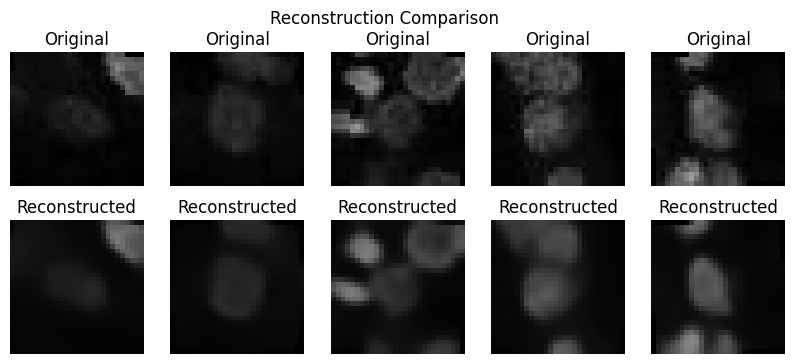

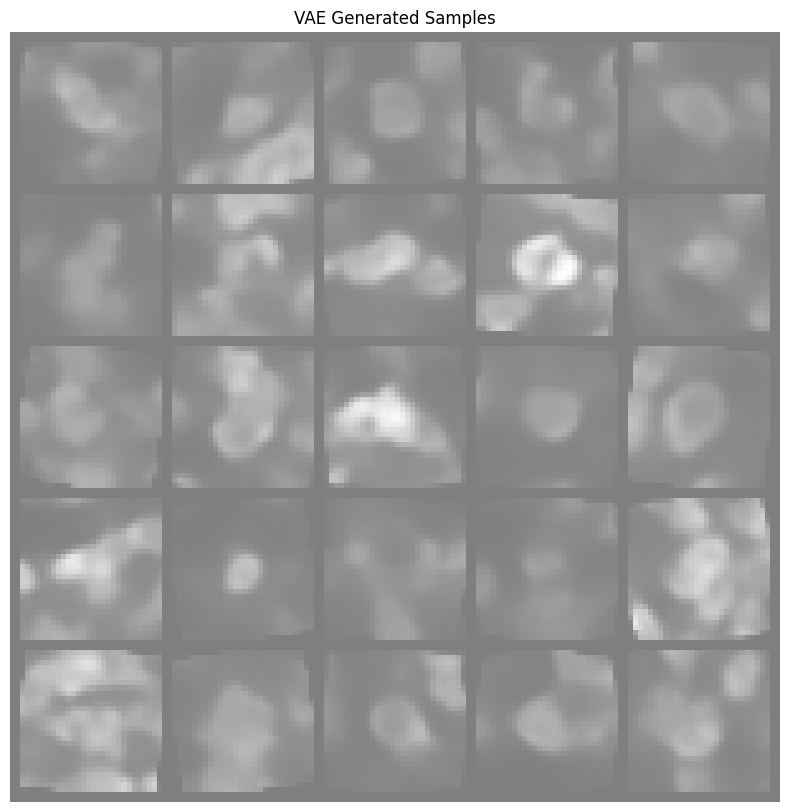

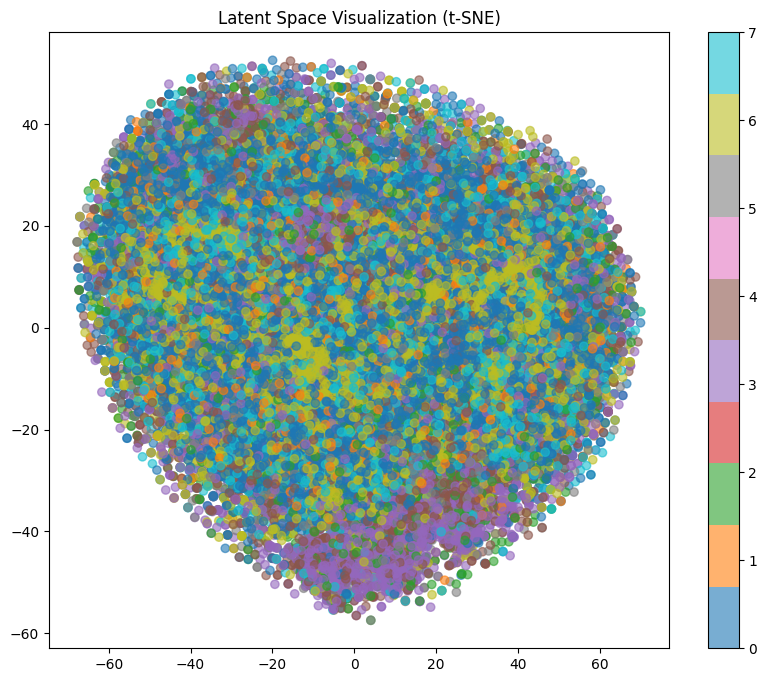


=== Additional Task: Training Conditional VAEs ===

=== Training CVAE on BreastMNIST (MRI) ===


100%|██████████| 560k/560k [00:01<00:00, 457kB/s]


BreastMNIST (MRI) has 2 classes


Epoch 1:   0%|          | 0/5 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


...

Epoch 19: Train Loss: 0.0429, Val Loss: 0.0449, LR: 1.85e-06


Epoch 20:   0%|          | 0/5 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


Epoch 20: 100%|██████████| 5/5 [00:02<00:00,  1.87it/s]


Epoch 20: Train Loss: 0.0427, Val Loss: 0.0447, LR: 0.00e+00
Saved CVAE model to models/cvae_breast.pth
Generating CVAE samples for BreastMNIST (MRI)...


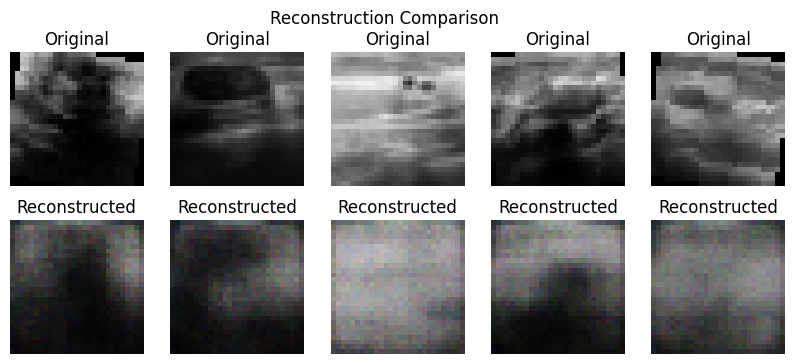

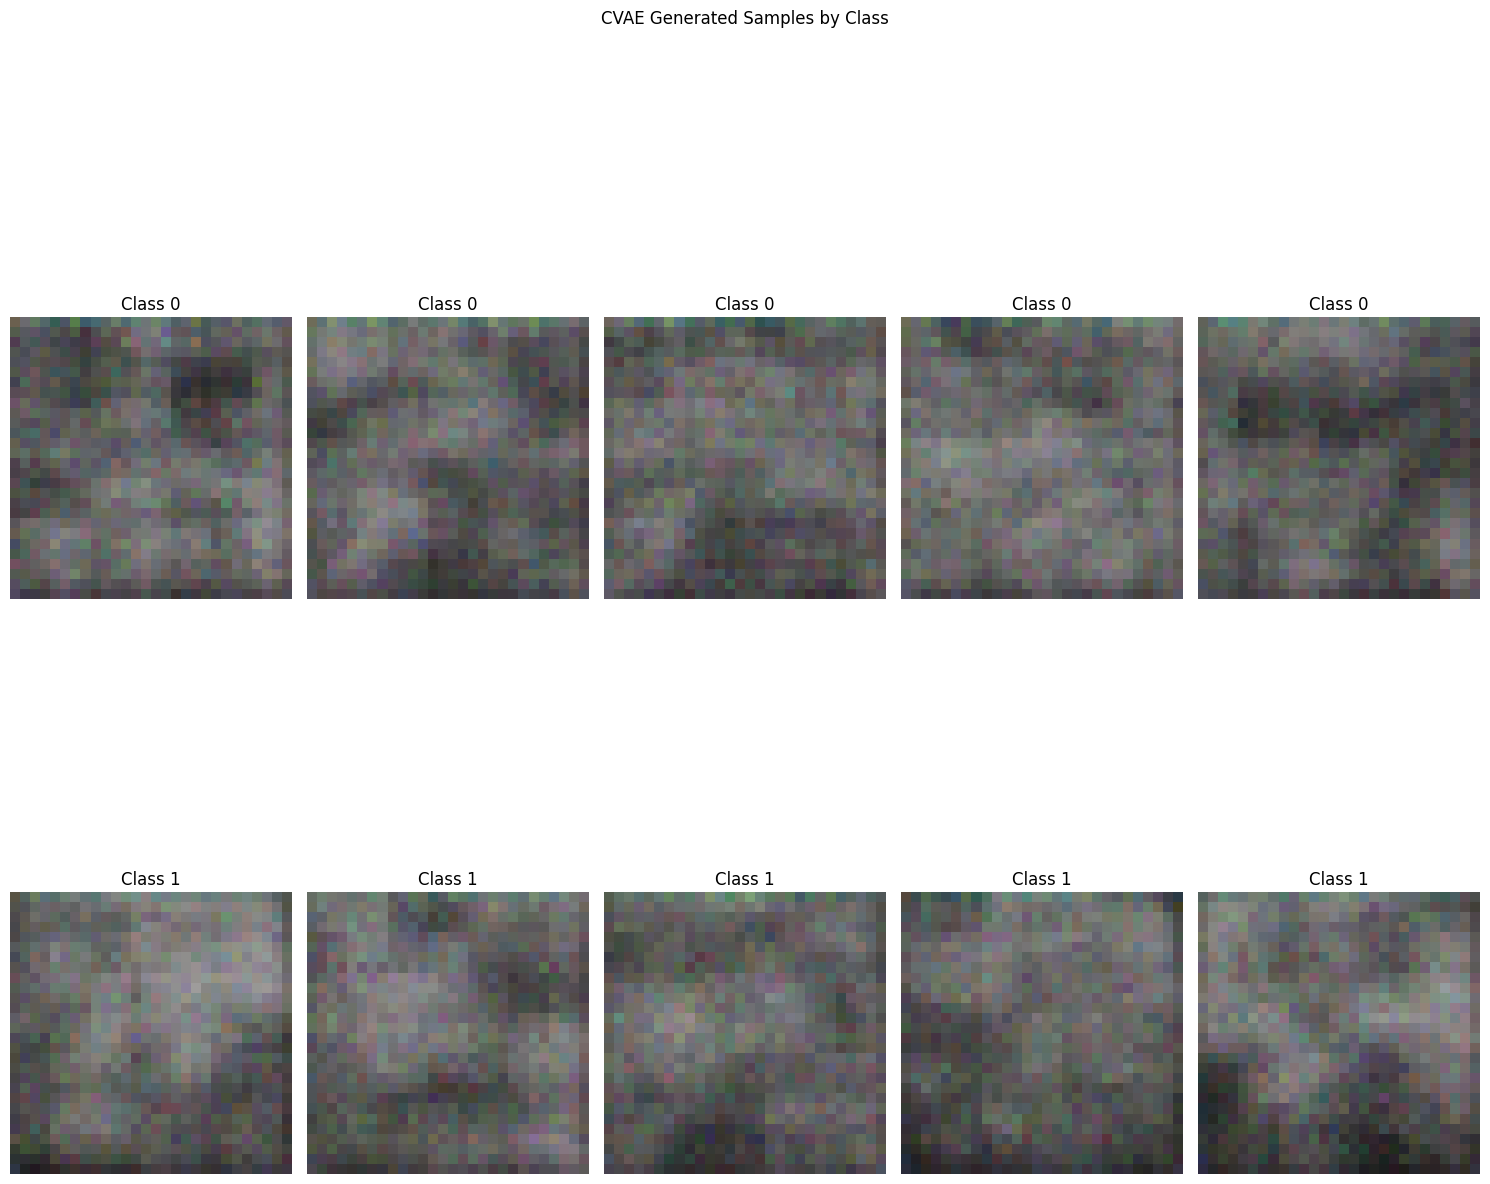

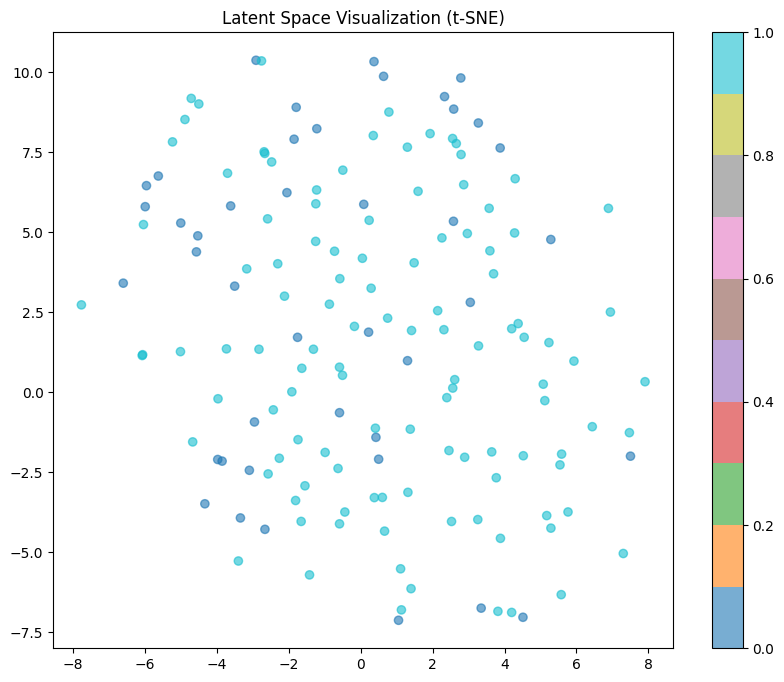


=== Training CVAE on ChestMNIST (X-ray) ===


100%|██████████| 82.8M/82.8M [01:51<00:00, 744kB/s]


ChestMNIST (X-ray) has 14 classes


Epoch 1:   0%|          | 0/614 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 14])


...

Epoch 19: Train Loss: 0.0084, Val Loss: 0.0084, LR: 1.85e-06


Epoch 20:   0%|          | 0/614 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 14])


Epoch 20: 100%|██████████| 614/614 [05:02<00:00,  2.03it/s]


Epoch 20: Train Loss: 0.0084, Val Loss: 0.0083, LR: 0.00e+00
Saved CVAE model to models/cvae_chest.pth
Generating CVAE samples for ChestMNIST (X-ray)...


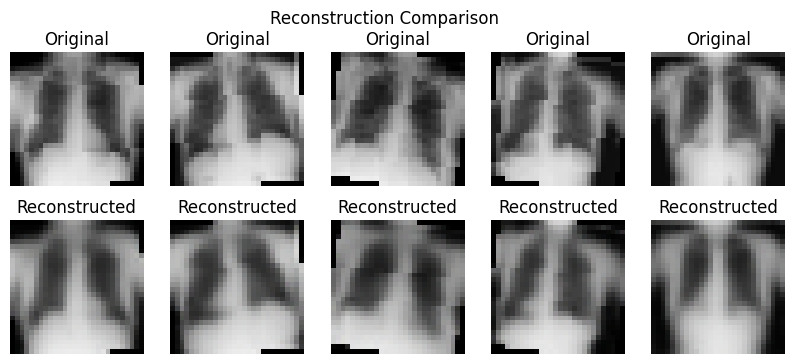

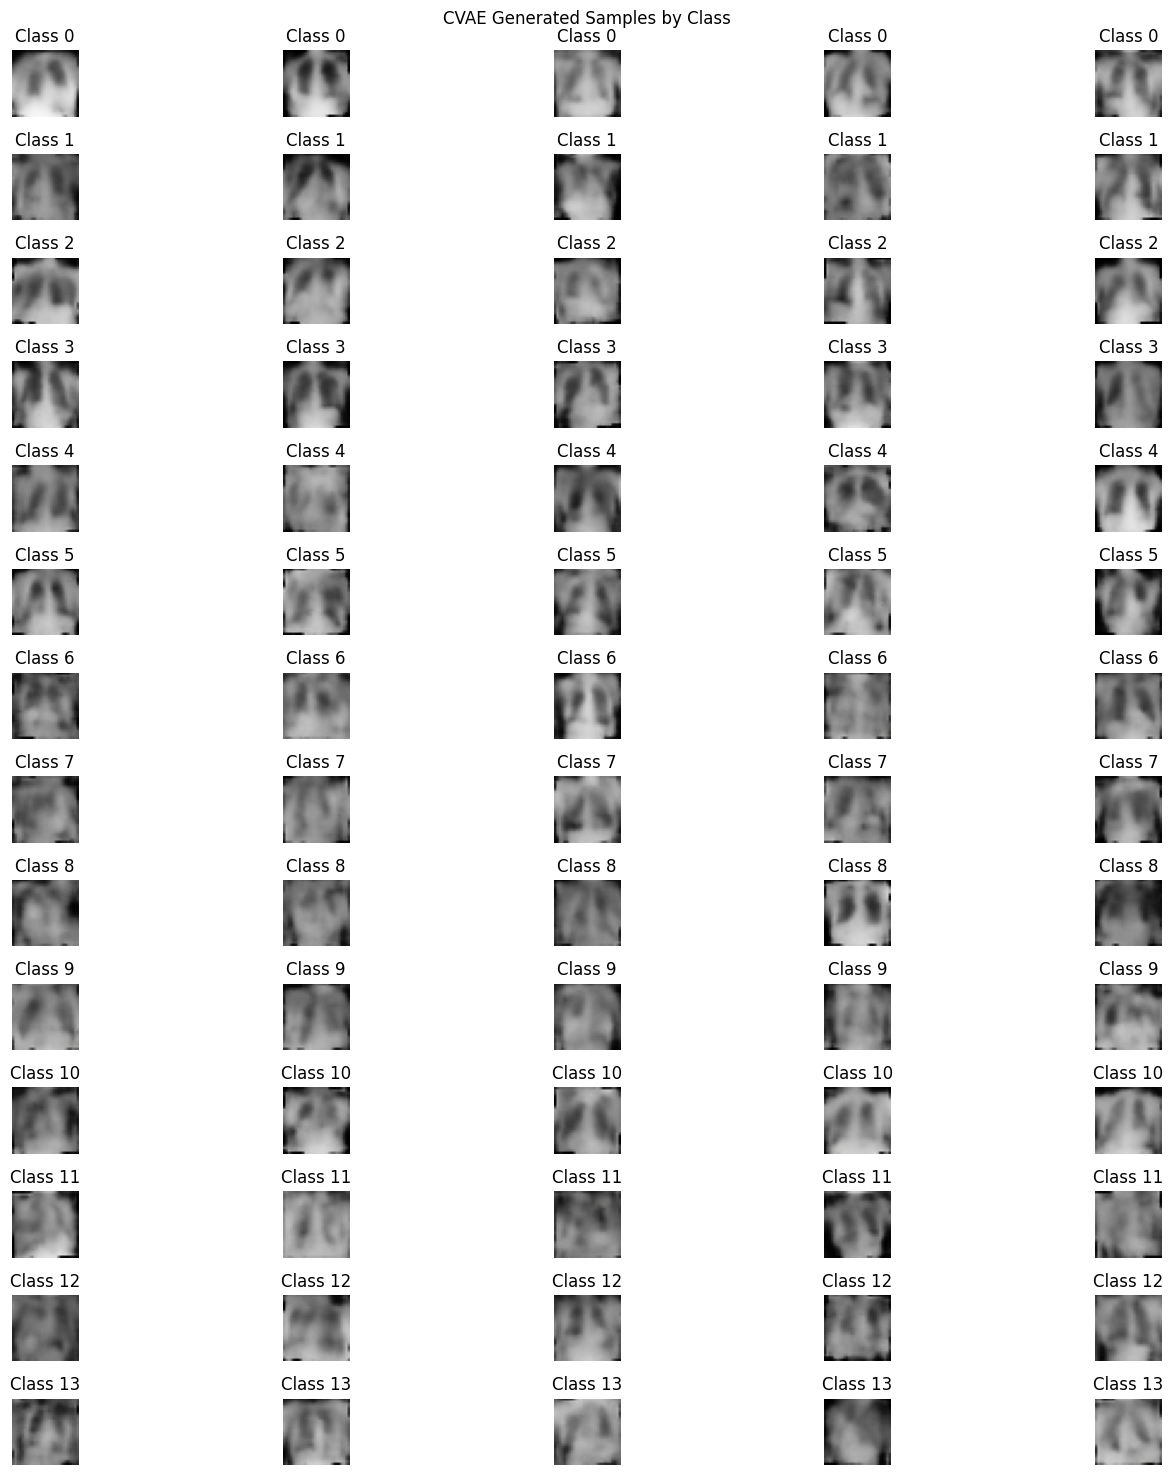

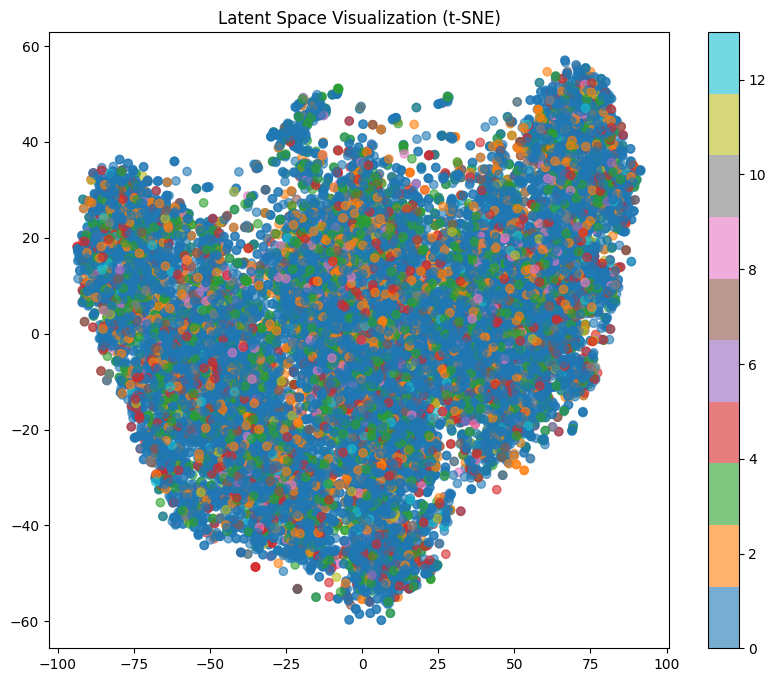


=== Training CVAE on PathMNIST (Pathology) ===


100%|██████████| 206M/206M [00:13<00:00, 15.0MB/s]


PathMNIST (Pathology) has 9 classes


Epoch 1:   0%|          | 0/704 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


...

Epoch 19: Train Loss: 0.0165, Val Loss: 0.0165, LR: 1.85e-06


Epoch 20:   0%|          | 0/704 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


Epoch 20: 100%|██████████| 704/704 [05:50<00:00,  2.01it/s]


Epoch 20: Train Loss: 0.0165, Val Loss: 0.0165, LR: 0.00e+00
Saved CVAE model to models/cvae_path.pth
Generating CVAE samples for PathMNIST (Pathology)...


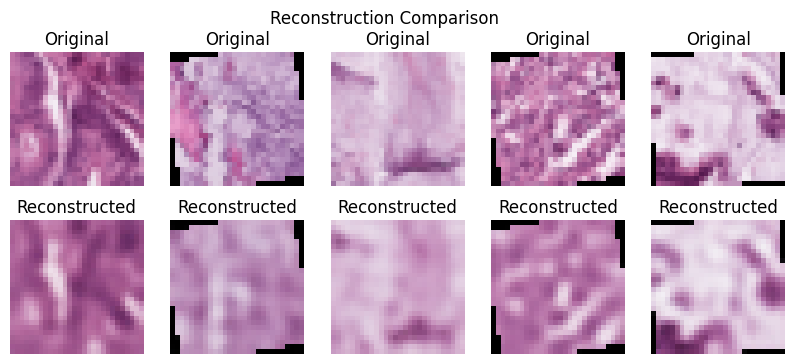

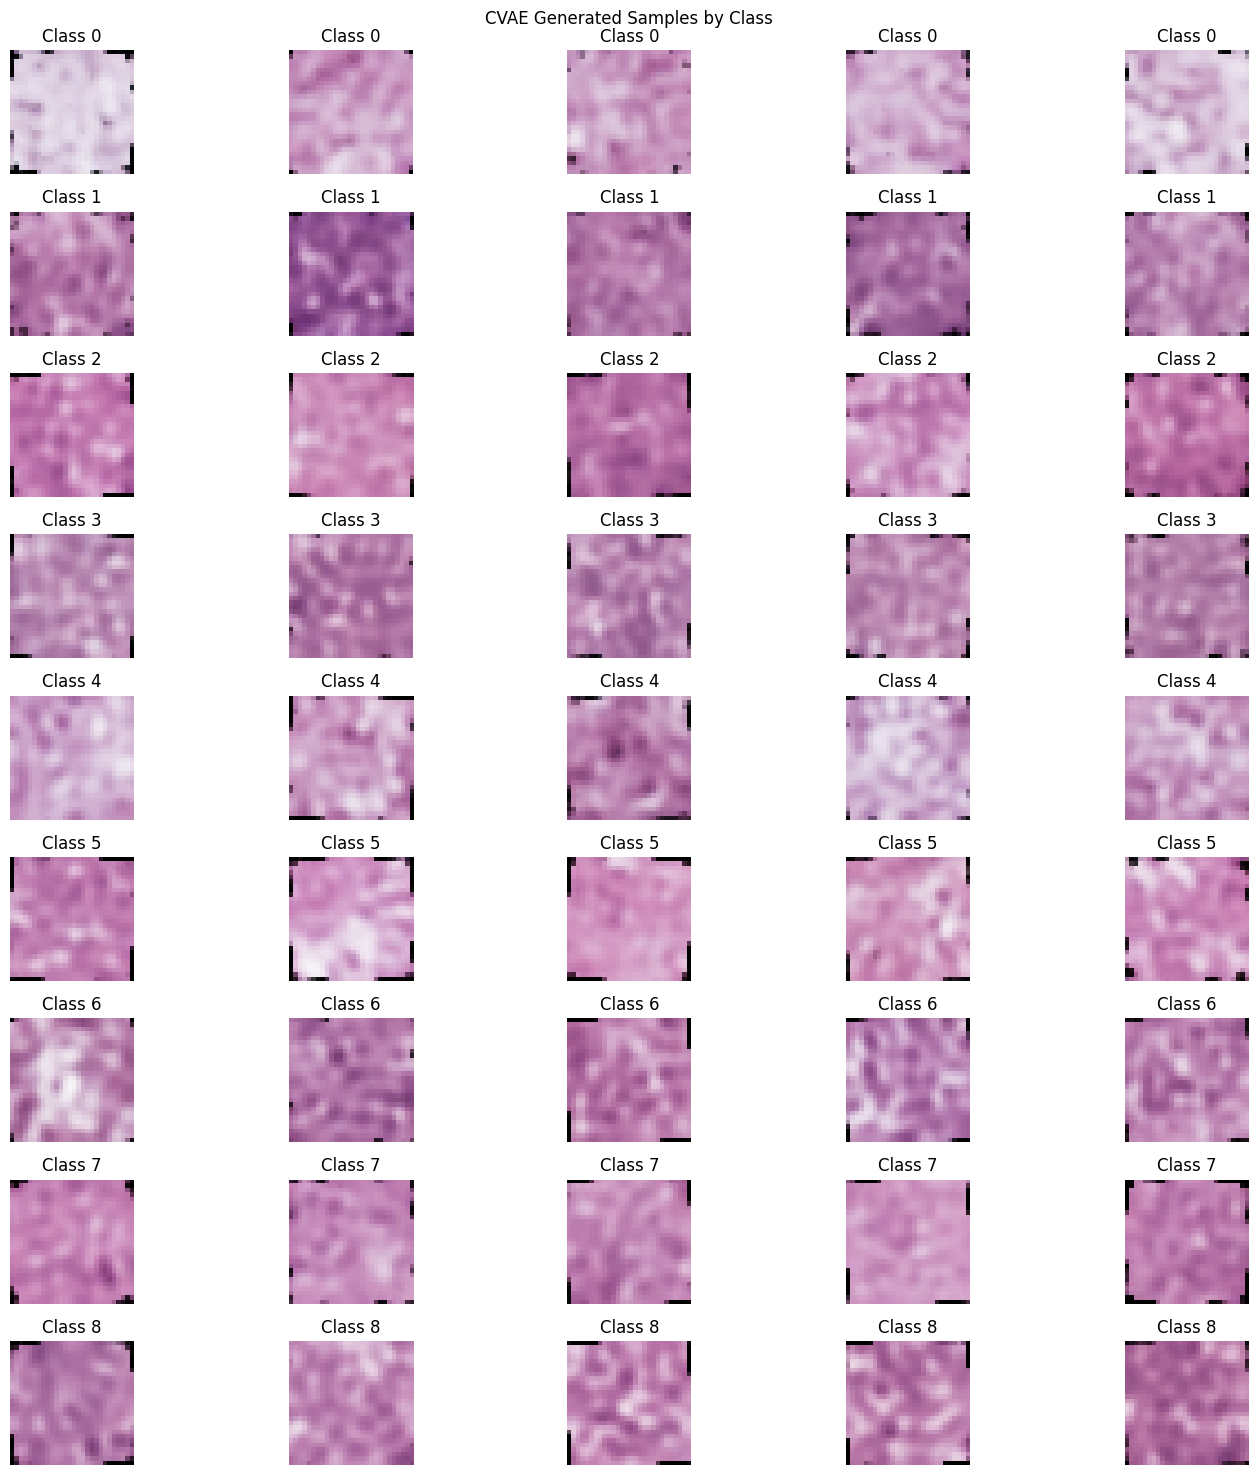

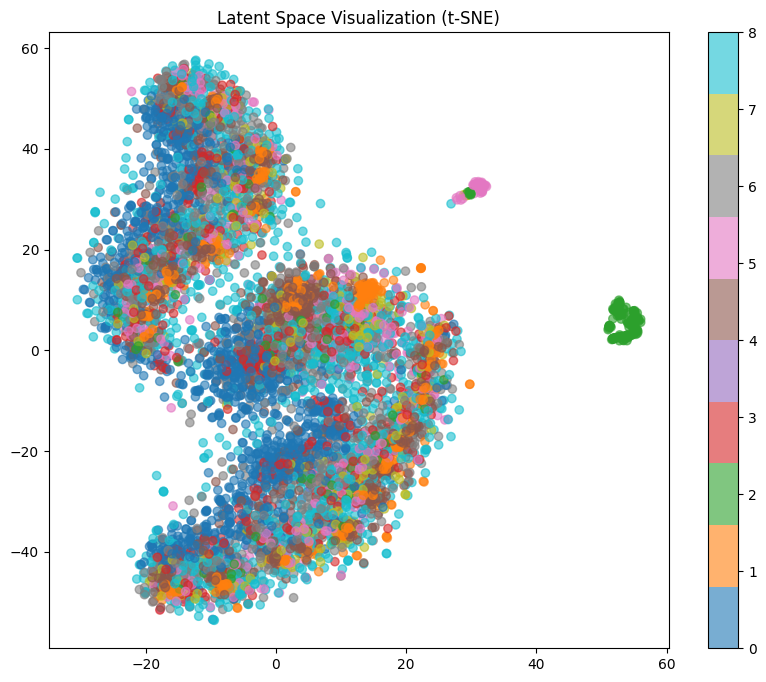


=== Training CVAE on DermaMNIST (Dermatology) ===


100%|██████████| 19.7M/19.7M [00:01<00:00, 11.1MB/s]


DermaMNIST (Dermatology) has 7 classes


Epoch 1:   0%|          | 0/55 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


...

Epoch 19: Train Loss: 0.0118, Val Loss: 0.0114, LR: 1.85e-06


Epoch 20:   0%|          | 0/55 [00:00<?, ?it/s]

Input image shape: torch.Size([128, 3, 28, 28])
Input label shape: torch.Size([128, 1])


Epoch 20: 100%|██████████| 55/55 [00:27<00:00,  1.99it/s]


Epoch 20: Train Loss: 0.0117, Val Loss: 0.0113, LR: 0.00e+00
Saved CVAE model to models/cvae_derma.pth
Generating CVAE samples for DermaMNIST (Dermatology)...


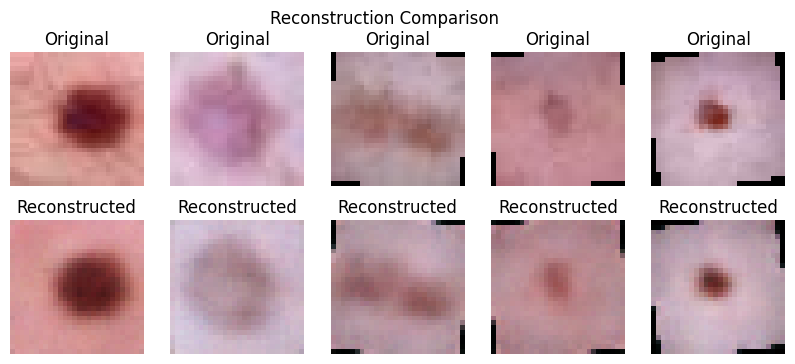

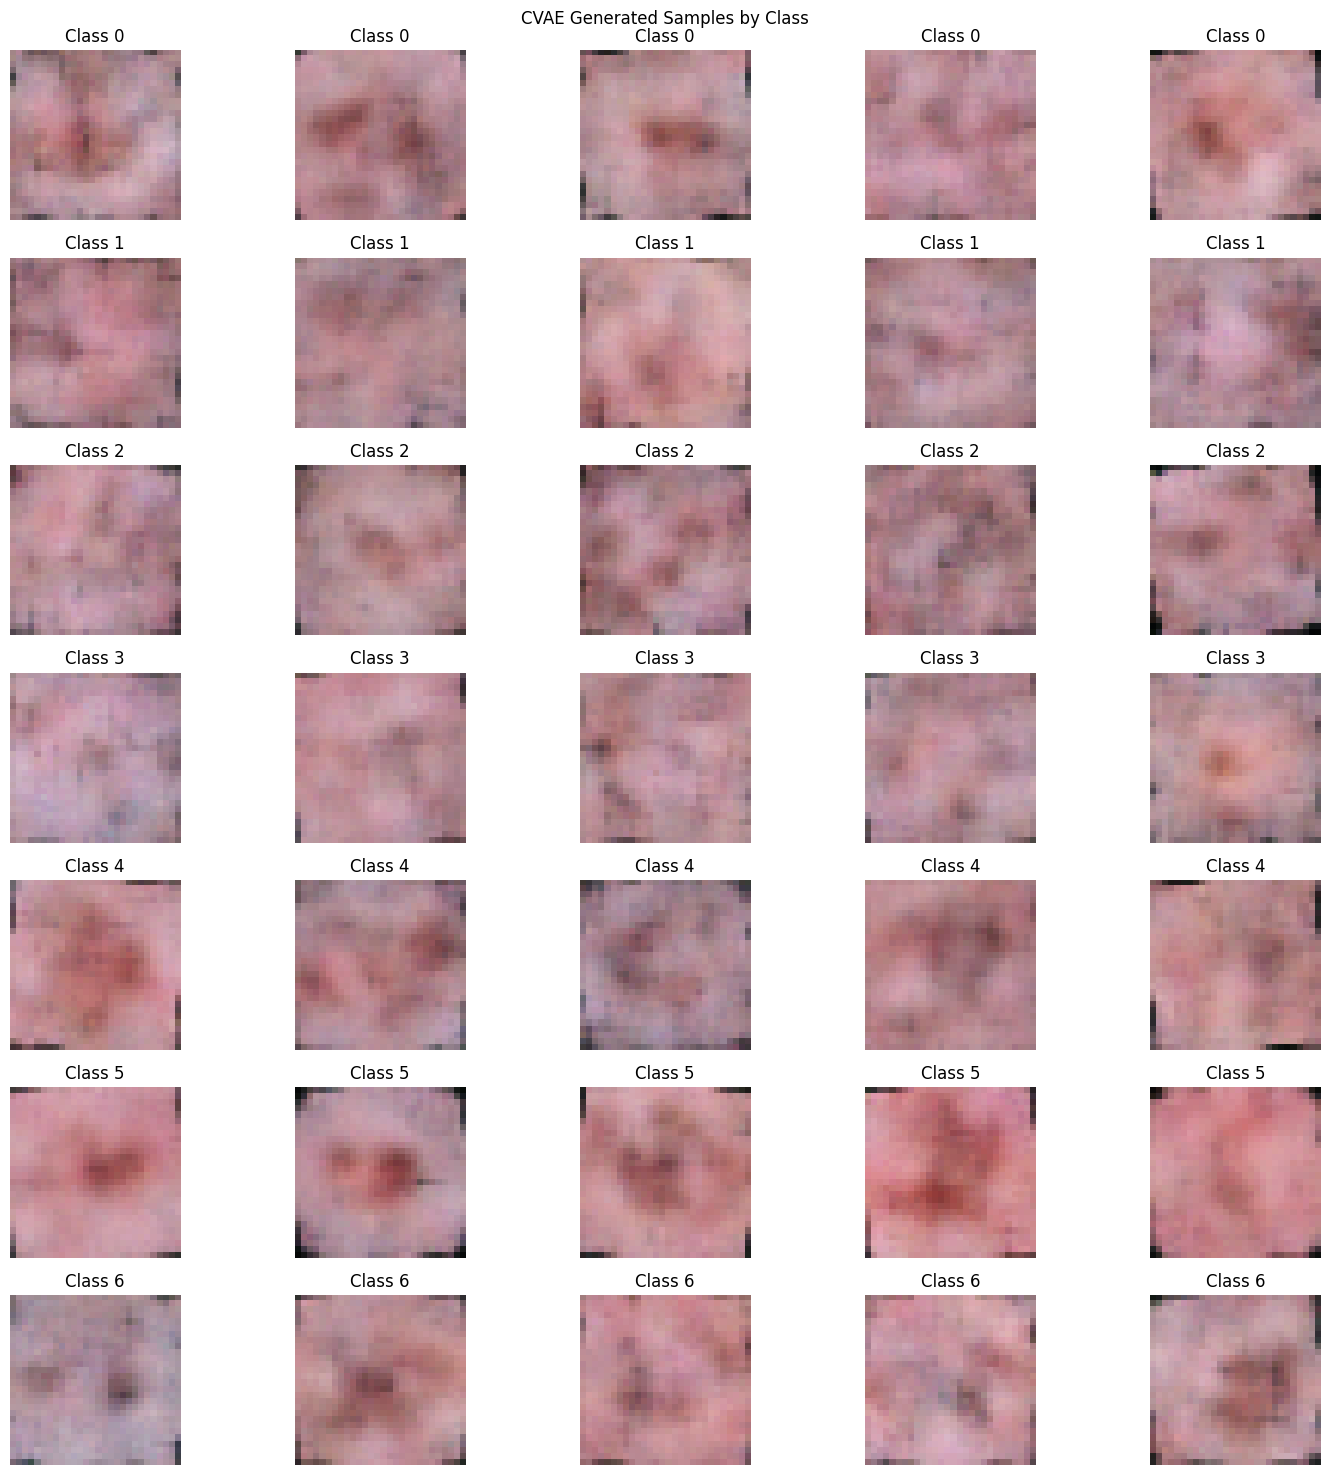

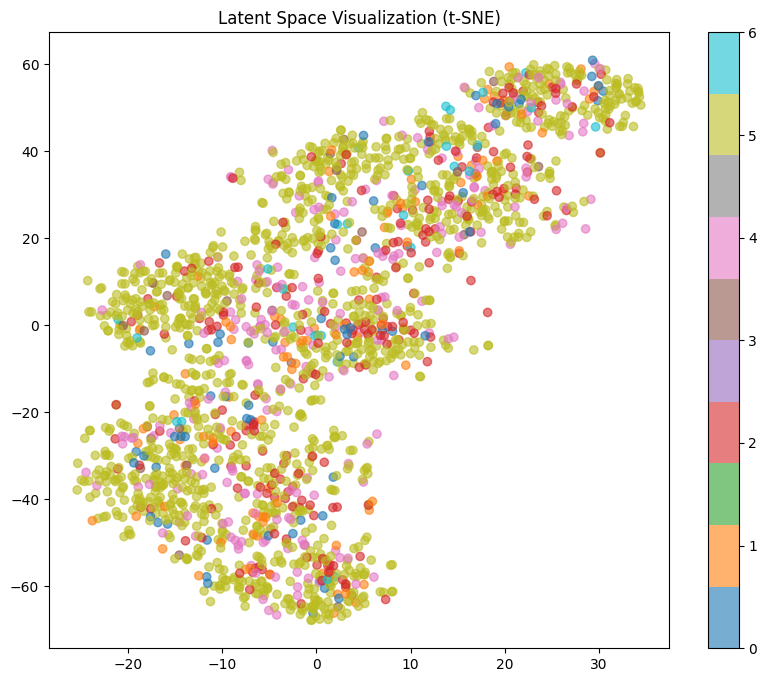

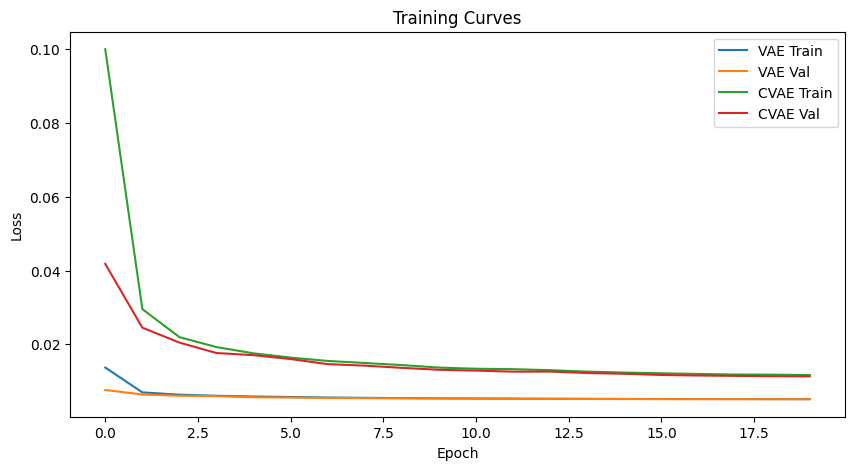


Zipping results...
  adding: models/ (stored 0%)
  adding: models/cvae_derma.pth (deflated 8%)
  adding: models/cvae_chest.pth (deflated 7%)
  adding: models/cvae_path.pth (deflated 7%)
  adding: models/vae_tissue.pth (deflated 7%)
  adding: models/cvae_breast.pth (deflated 8%)
  adding: images/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete! All results saved to medmnist_vae_results.zip


In [ ]:
if __name__ == "__main__":
    # Create directories for saving
    os.makedirs('models', exist_ok=True)
    os.makedirs('images', exist_ok=True)

    # Basic Task: Standard VAE
    print("=== Basic Task: Training Standard VAE on TissueMNIST ===")
    train_loader, val_loader, test_loader, _ = get_dataloader('tissue')
    vae = VAE(z_dim=config['z_dim']).to(device)
    vae_train_loss, vae_val_loss = train_model(vae, train_loader, val_loader)

    # Save VAE model
    vae_model_path = 'models/vae_tissue.pth'
    torch.save(vae.state_dict(), vae_model_path)
    print(f"Saved VAE model to {vae_model_path}")

    # Generate and save samples for VAE
    print("Generating VAE samples...")
    visualize_results(vae, test_loader)
    plot_latent_space(vae, test_loader)

    # Additional Task: Conditional VAE (4 modalities)
    print("\n=== Additional Task: Training Conditional VAEs ===")
    datasets = [
        ('breast', 'BreastMNIST (MRI)'),
        ('chest', 'ChestMNIST (X-ray)'),
        ('path', 'PathMNIST (Pathology)'),
        ('derma', 'DermaMNIST (Dermatology)')
    ]

    for dataset_code, dataset_name in datasets:
        print(f"\n=== Training CVAE on {dataset_name} ===")
        train_loader, val_loader, test_loader, n_classes = get_dataloader(dataset_code)
        print(f"{dataset_name} has {n_classes} classes")
        cvae = CVAE(n_classes, z_dim=config['z_dim']).to(device)
        cvae_train_loss, cvae_val_loss = train_model(cvae, train_loader, val_loader, is_cvae=True)

        # Save CVAE model
        cvae_model_path = f'models/cvae_{dataset_code}.pth'
        torch.save(cvae.state_dict(), cvae_model_path)
        print(f"Saved CVAE model to {cvae_model_path}")

        # Generate and save samples for CVAE
        print(f"Generating CVAE samples for {dataset_name}...")
        visualize_results(cvae, test_loader, is_cvae=True, n_classes=n_classes)
        plot_latent_space(cvae, test_loader, is_cvae=True)

    # Plot training curves
    plt.figure(figsize=(10, 5))
    plt.plot(vae_train_loss, label='VAE Train')
    plt.plot(vae_val_loss, label='VAE Val')
    plt.plot(cvae_train_loss, label='CVAE Train')
    plt.plot(cvae_val_loss, label='CVAE Val')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Curves')
    plt.legend()
    plt.show()

    # Zip and download all results
    print("\nZipping results...")
    !zip -r medmnist_vae_results.zip models images

    print("Downloading results...")
    files.download('medmnist_vae_results.zip')
    print("Download complete! All results saved to medmnist_vae_results.zip")